# Cell 1 │ Installs & Imports

In [1]:
import math, time, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import RandAugment

import matplotlib.pyplot as plt

# ── Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")



Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4


# Cell 2 │ Model Config

In [3]:

config = {
    #  Image
    "image_size":   32,
    "num_channels": 3,

    #  Patch
    # patch_size=4 → 8×8 = 64 patches
    "patch_size":   4,

    # ── Architecture
    "hidden_size":          192,
    "num_hidden_layers":     12,
    "num_attention_heads":    3,    # 192 / 3 = 64 per head
    "intermediate_size":  4*192,   # 768 — standard 4× ratio

    # ── Regularisation
    "hidden_dropout_prob":          0.0,
    "attention_probs_dropout_prob": 0.0,
    # Stochastic depth max drop rate (applied linearly across layers)
    "drop_path_rate":               0.1,

    # ── Label smoothing
    "label_smoothing": 0.1,

    # ── Init
    "initializer_range": 0.02,

    # ── Task
    "num_classes": 10,
    "qkv_bias":    True,
}

num_patches = (config["image_size"] // config["patch_size"]) ** 2
print(f"Patches per image : {num_patches}  ({config['image_size']//config['patch_size']}×grid)")
print(f"Sequence length   : {num_patches+1}  (+ CLS)")
print(f"Hidden size       : {config['hidden_size']}")
print(f"Layers            : {config['num_hidden_layers']}")
print(f"Heads             : {config['num_attention_heads']}")
print(f"Head dim          : {config['hidden_size']//config['num_attention_heads']}")



Patches per image : 64  (8×grid)
Sequence length   : 65  (+ CLS)
Hidden size       : 192
Layers            : 12
Heads             : 3
Head dim          : 64


# Cell 3 │ Stochastic Depth (DropPath)

In [4]:

class DropPath(nn.Module):

    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob   = 1 - self.drop_prob
        # Shape: (batch, 1, 1) — drop entire samples, not individual elements
        shape       = (x.shape[0],) + (1,) * (x.ndim - 1)
        rand_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        rand_tensor = torch.floor(rand_tensor + keep_prob)
        return x * rand_tensor / keep_prob


# %%

# Cell 4 │ Patch Embeddings

In [5]:

class PatchEmbeddings(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.num_patches = (config["image_size"] // config["patch_size"]) ** 2
        # Conv2d with kernel=stride=patch_size does patching + projection
        self.projection  = nn.Conv2d(
            config["num_channels"],
            config["hidden_size"],
            kernel_size = config["patch_size"],
            stride      = config["patch_size"],
        )

    def forward(self, x):
        x = self.projection(x)      # (B, D, H/P, W/P)
        x = x.flatten(2)            # (B, D, N)
        x = x.transpose(1, 2)       # (B, N, D)
        return x



# Cell 5 │ Embedding

In [6]:

class Embeddings(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.patch_embeddings = PatchEmbeddings(config)
        N = self.patch_embeddings.num_patches

        self.cls_token           = nn.Parameter(torch.randn(1, 1, config["hidden_size"]))
        self.position_embeddings = nn.Parameter(torch.randn(1, N + 1, config["hidden_size"]))
        self.dropout             = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x):
        x          = self.patch_embeddings(x)
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x          = torch.cat([cls_tokens, x], dim=1)
        x          = x + self.position_embeddings
        return self.dropout(x)


#  Cell 6 │ Attention Head

In [7]:

class AttentionHead(nn.Module):

    def __init__(self, hidden_size, head_size, dropout, bias=True):
        super().__init__()
        self.head_size = head_size
        self.query  = nn.Linear(hidden_size, head_size, bias=bias)
        self.key    = nn.Linear(hidden_size, head_size, bias=bias)
        self.value  = nn.Linear(hidden_size, head_size, bias=bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        scores  = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(self.head_size)
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        return torch.matmul(weights, V), weights



#  Cell 7 │ Multi-Head Attentio

In [8]:

class MultiHeadAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.hidden_size = config["hidden_size"]
        self.num_heads   = config["num_attention_heads"]
        self.head_size   = self.hidden_size // self.num_heads

        self.heads = nn.ModuleList([
            AttentionHead(
                self.hidden_size, self.head_size,
                config["attention_probs_dropout_prob"],
                config["qkv_bias"],
            )
            for _ in range(self.num_heads)
        ])
        self.output_projection = nn.Linear(self.hidden_size, self.hidden_size)
        self.output_dropout    = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x, output_attentions=False):
        head_outputs = [head(x) for head in self.heads]
        attn_out     = torch.cat([o for o, _ in head_outputs], dim=-1)
        attn_out     = self.output_projection(attn_out)
        attn_out     = self.output_dropout(attn_out)
        if output_attentions:
            weights = torch.stack([w for _, w in head_outputs], dim=1)
            return attn_out, weights
        return attn_out, None



# Cell 8 │ MLP (GELU activation)

In [9]:

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.dense1  = nn.Linear(config["hidden_size"], config["intermediate_size"])
        self.gelu    = nn.GELU()
        self.dense2  = nn.Linear(config["intermediate_size"], config["hidden_size"])
        self.dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x):
        return self.dropout(self.dense2(self.dropout(self.gelu(self.dense1(x)))))



#  Cell 9 │ Block — Pre-LN + DropPath

In [11]:

class Block(nn.Module):

    def __init__(self, config, drop_path_rate=0.0):
        super().__init__()
        self.layernorm_1 = nn.LayerNorm(config["hidden_size"])
        self.attention   = MultiHeadAttention(config)
        self.layernorm_2 = nn.LayerNorm(config["hidden_size"])
        self.mlp         = MLP(config)

        self.drop_path   = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x, output_attentions=False):
        attn_out, attn_weights = self.attention(
            self.layernorm_1(x), output_attentions=output_attentions
        )
        x = x + self.drop_path(attn_out)           # stochastic residual
        x = x + self.drop_path(self.mlp(self.layernorm_2(x)))
        return x, attn_weights



#  Cell 10 │ Encoder — linearly increasing DropPath per layer

In [12]:

class Encoder(nn.Module):

    def __init__(self, config):
        super().__init__()
        N          = config["num_hidden_layers"]
        max_rate   = config["drop_path_rate"]

        drop_rates = [max_rate * i / (N - 1) for i in range(N)]

        self.blocks = nn.ModuleList([
            Block(config, drop_path_rate=drop_rates[i])
            for i in range(N)
        ])

    def forward(self, x, output_attentions=False):
        all_attentions = []
        for block in self.blocks:
            x, attn = block(x, output_attentions=output_attentions)
            if output_attentions and attn is not None:
                all_attentions.append(attn)
        return x, (all_attentions if output_attentions else None)



#  CELL 11 │ Full ViT Model

In [13]:

class ViTForImageClassification(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config      = config
        self.embedding   = Embeddings(config)
        self.encoder     = Encoder(config)
        self.layernorm   = nn.LayerNorm(config["hidden_size"])
        self.classifier  = nn.Linear(config["hidden_size"], config["num_classes"])
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.normal_(m.weight, 0.0, self.config["initializer_range"])
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x, output_attentions=False):
        x                  = self.embedding(x)
        x, all_attentions  = self.encoder(x, output_attentions)
        x                  = self.layernorm(x)
        cls_output         = x[:, 0]
        logits             = self.classifier(cls_output)
        return logits, all_attentions


# ── Build model
model = ViTForImageClassification(config).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters : {total/1e6:.2f}M")

# Smoke test
dummy  = torch.randn(4, 3, 32, 32, device=DEVICE)
logits, _ = model(dummy)
print(f"Output shape     : {logits.shape}")   # (4, 10)



Model parameters : 5.36M
Output shape     : torch.Size([4, 10])


# CELL 12 │ Data Augmentation

In [14]:

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
CLASSES      = ["airplane","automobile","bird","cat","deer",
                "dog","frog","horse","ship","truck"]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

BATCH_SIZE = 128

train_dataset = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")



100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Train batches : 391
Test  batches : 79


# CELL 13 │ MixUp & CutMix

In [15]:

def mixup(images, labels, alpha=0.8):
    """
    images : (B, C, H, W)
    labels : (B,) integer class ids
    returns mixed images and (label_a, label_b, lambda) for loss computation
    """
    lam    = np.random.beta(alpha, alpha)
    idx    = torch.randperm(images.size(0), device=images.device)
    mixed  = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


def cutmix(images, labels, alpha=1.0):
    """
    Cut a random rectangle from image[idx] and paste onto image.
    """
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = images.shape
    idx  = torch.randperm(B, device=images.device)

    # Rectangle dimensions
    cut_ratio = math.sqrt(1.0 - lam)
    cut_h     = int(H * cut_ratio)
    cut_w     = int(W * cut_ratio)

    # Random centre
    cx = random.randint(0, W)
    cy = random.randint(0, H)

    # Clamp to image boundaries
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)

    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]

    # Recompute lambda from actual crop area
    lam = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return mixed, labels, labels[idx], lam


def mixup_cutmix_loss(criterion, logits, label_a, label_b, lam):
    """
    Compute the blended cross-entropy loss for MixUp/CutMix.
    """
    return lam * criterion(logits, label_a) + (1 - lam) * criterion(logits, label_b)


print("MixUp and CutMix ready")



MixUp and CutMix ready


# CELL 14 │ Label Smoothing Loss

In [16]:

criterion = nn.CrossEntropyLoss(label_smoothing=config["label_smoothing"])
print(f"Using CrossEntropyLoss with label_smoothing={config['label_smoothing']}")



Using CrossEntropyLoss with label_smoothing=0.1


# CELL 15 │ Optimiser & LR Schedule

In [17]:

EPOCHS       = 200
LR           = 1e-3
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.999),
)

# Phase 1 — linear warmup: lr goes from LR/100 → LR over WARMUP_EPOCHS
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor = 0.01,
    end_factor   = 1.0,
    total_iters  = WARMUP_EPOCHS,
)
# Phase 2 — cosine decay: lr goes from LR → ~0 over remaining epochs
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = EPOCHS - WARMUP_EPOCHS,
    eta_min = 1e-6,
)
# Chain them: first WARMUP_EPOCHS epochs use warmup, rest use cosine
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers = [warmup_scheduler, cosine_scheduler],
    milestones = [WARMUP_EPOCHS],
)

print(f"Epochs       : {EPOCHS}")
print(f"LR           : {LR}  (warmup {WARMUP_EPOCHS} → cosine decay)")
print(f"Weight decay : {WEIGHT_DECAY}")
print(f"Batch size   : {BATCH_SIZE}")



Epochs       : 200
LR           : 0.001  (warmup 5 → cosine decay)
Weight decay : 0.05
Batch size   : 128


# CELL 16 │ Training & Evaluation Functions

In [18]:

MIXUP_PROB   = 0.5   # probability of applying MixUp per batch
CUTMIX_PROB  = 0.5   # probability of applying CutMix (given MixUp not applied)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # ── Decide which batch augmentation to apply
        r = random.random()
        if r < MIXUP_PROB:
            images, la, lb, lam = mixup(images, labels)
            use_mix = True
        elif r < MIXUP_PROB + CUTMIX_PROB:
            images, la, lb, lam = cutmix(images, labels)
            use_mix = True
        else:
            use_mix = False

        # ── Forward
        optimizer.zero_grad()
        logits, _ = model(images)

        if use_mix:
            loss = mixup_cutmix_loss(criterion, logits, la, lb, lam)
        else:
            loss = criterion(logits, labels)

        # ── Backward
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits, _       = model(images)
        loss            = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


# CELL 17 │ Training Loop

In [19]:

history  = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}
best_acc = 0.0
t_start  = time.time()

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} "
      f"{'Test Loss':>10} {'Test Acc':>10} {'LR':>9} {'Time':>6}")
print("─" * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "best_vit_90.pth")

    lr_now  = scheduler.get_last_lr()[0]
    elapsed = time.time() - t0


    marker = "◀ best" if te_acc == best_acc else ""
    print(f"{epoch:>6} {tr_loss:>11.4f} {tr_acc:>10.3f} "
          f"{te_loss:>10.4f} {te_acc:>10.3f} {lr_now:>9.2e} {elapsed:>5.1f}s  {marker}")

total_time = time.time() - t_start
print(f"\nTraining complete in {total_time/60:.1f} min")
print(f"Best test accuracy : {best_acc*100:.2f}%")


 Epoch  Train Loss  Train Acc  Test Loss   Test Acc        LR   Time
──────────────────────────────────────────────────────────────────────
     1      2.2928      0.119     2.2012      0.175  2.08e-04  74.7s  ◀ best
     2      2.2185      0.168     2.0229      0.309  4.06e-04  75.8s  ◀ best
     3      2.1677      0.204     1.8709      0.357  6.04e-04  74.2s  ◀ best
     4      2.1403      0.217     1.8309      0.416  8.02e-04  74.6s  ◀ best
     5      2.1204      0.233     1.8328      0.405  1.00e-03  74.5s  
     6      2.1125      0.230     1.8021      0.428  1.00e-03  74.2s  ◀ best
     7      2.1052      0.232     1.7980      0.416  1.00e-03  74.2s  
     8      2.0745      0.250     1.7366      0.441  9.99e-04  74.2s  ◀ best
     9      2.0644      0.262     1.7077      0.461  9.99e-04  74.4s  ◀ best
    10      2.0402      0.267     1.6608      0.482  9.98e-04  74.5s  ◀ best
    11      2.0452      0.262     1.6682      0.493  9.98e-04  73.8s  ◀ best
    12      2.0246      0

# CELL 18 │ Training Curves

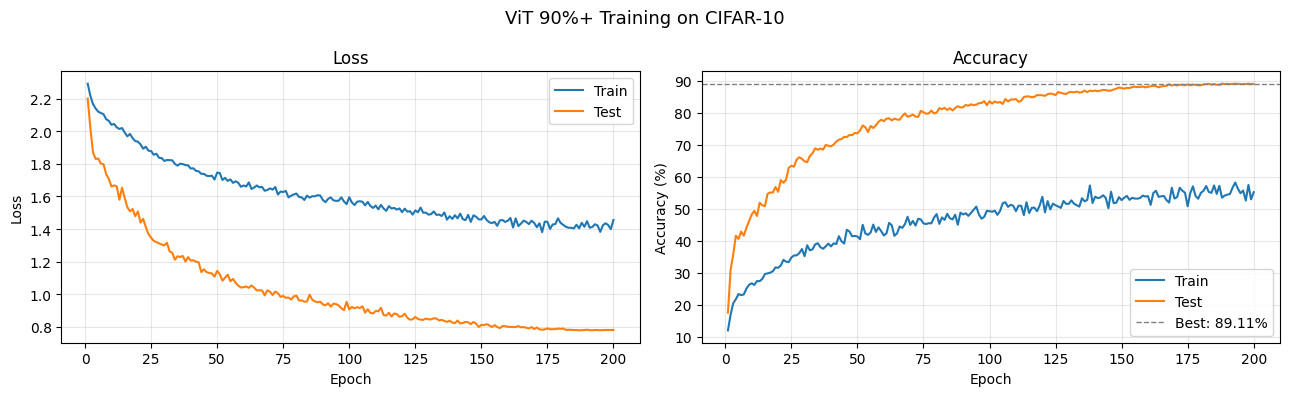

In [20]:

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train", linewidth=1.5)
ax1.plot(epochs_range, history["test_loss"],  label="Test",  linewidth=1.5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train", linewidth=1.5)
ax2.plot(epochs_range, [a*100 for a in history["test_acc"]],  label="Test",  linewidth=1.5)
ax2.axhline(best_acc*100, color="gray", linestyle="--", linewidth=1,
            label=f"Best: {best_acc*100:.2f}%")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("ViT 90%+ Training on CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()



# CELL 19 │ Final Evaluation

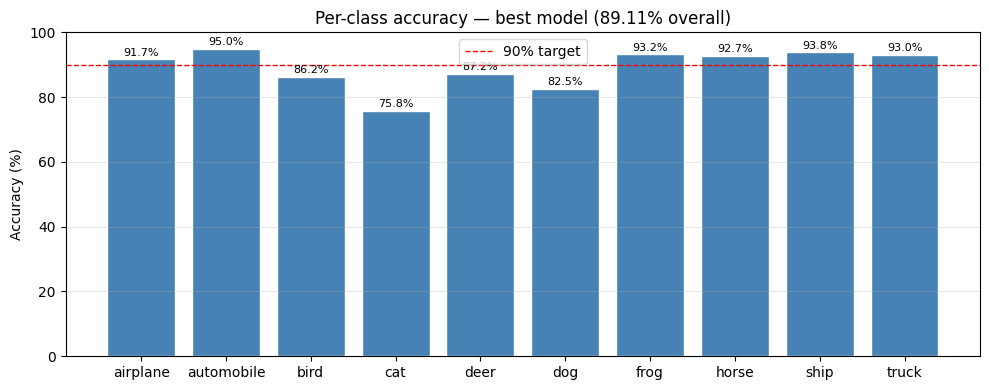


Overall test accuracy : 89.11%

Per-class:
  airplane      91.7%  ██████████████████
  automobile    95.0%  ███████████████████
  bird          86.2%  █████████████████
  cat           75.8%  ███████████████
  deer          87.2%  █████████████████
  dog           82.5%  ████████████████
  frog          93.2%  ██████████████████
  horse         92.7%  ██████████████████
  ship          93.8%  ██████████████████
  truck         93.0%  ██████████████████


In [21]:

# Load best checkpoint
model.load_state_dict(torch.load("best_vit_90.pth", map_location=DEVICE))
model.eval()

# Per-class accuracy
class_correct = torch.zeros(10)
class_total   = torch.zeros(10)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits, _      = model(images)
        preds          = logits.argmax(1)
        for c in range(10):
            mask = labels == c
            class_correct[c] += (preds[mask] == c).sum().item()
            class_total[c]   += mask.sum().item()

class_acc = (class_correct / class_total * 100).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASSES, class_acc, color="steelblue", edgecolor="white")
ax.set_ylim(0, 100)
ax.axhline(90, color="red", linestyle="--", linewidth=1, label="90% target")
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Per-class accuracy — best model ({best_acc*100:.2f}% overall)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

for bar, acc in zip(bars, class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nOverall test accuracy : {best_acc*100:.2f}%")
print(f"\nPer-class:")
for cls, acc in zip(CLASSES, class_acc):
    bar = "█" * int(acc / 5)
    print(f"  {cls:<12} {acc:>5.1f}%  {bar}")



# Cell | 20 Confusion Matrix

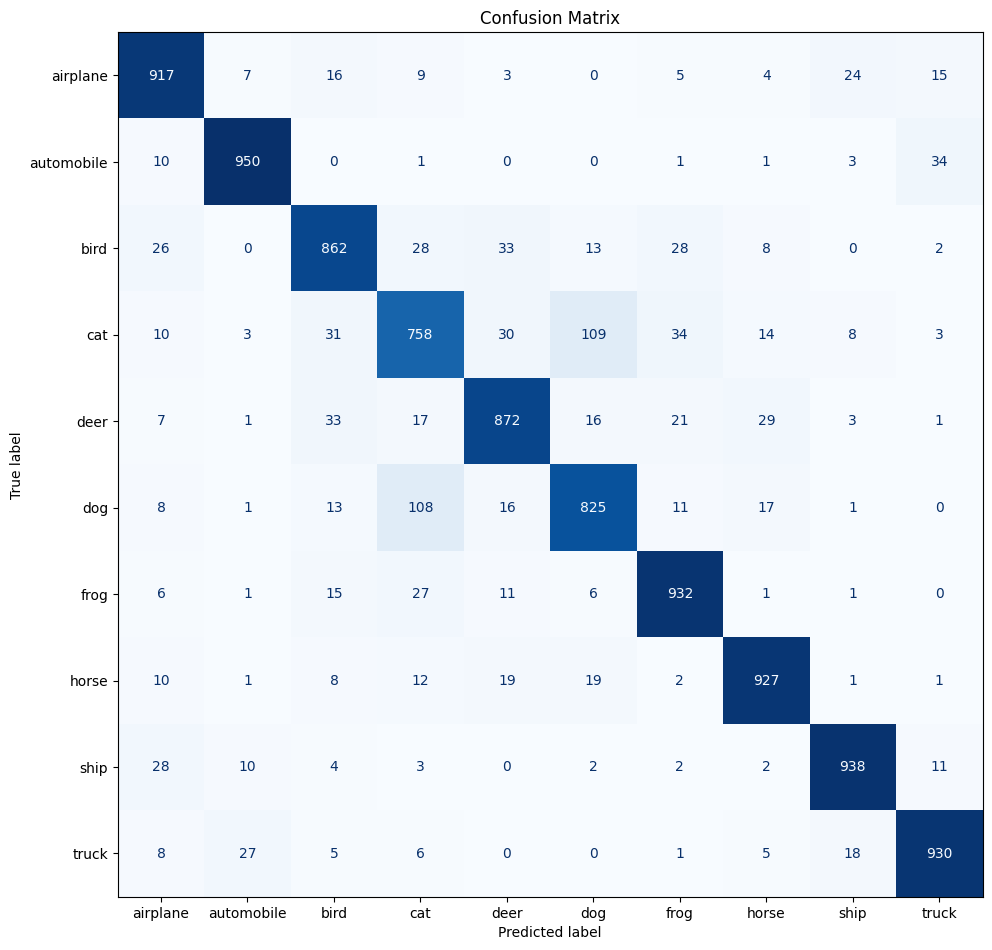

In [22]:


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        logits, _ = model(images.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# CELL 21 │ Attention Map Visualisation

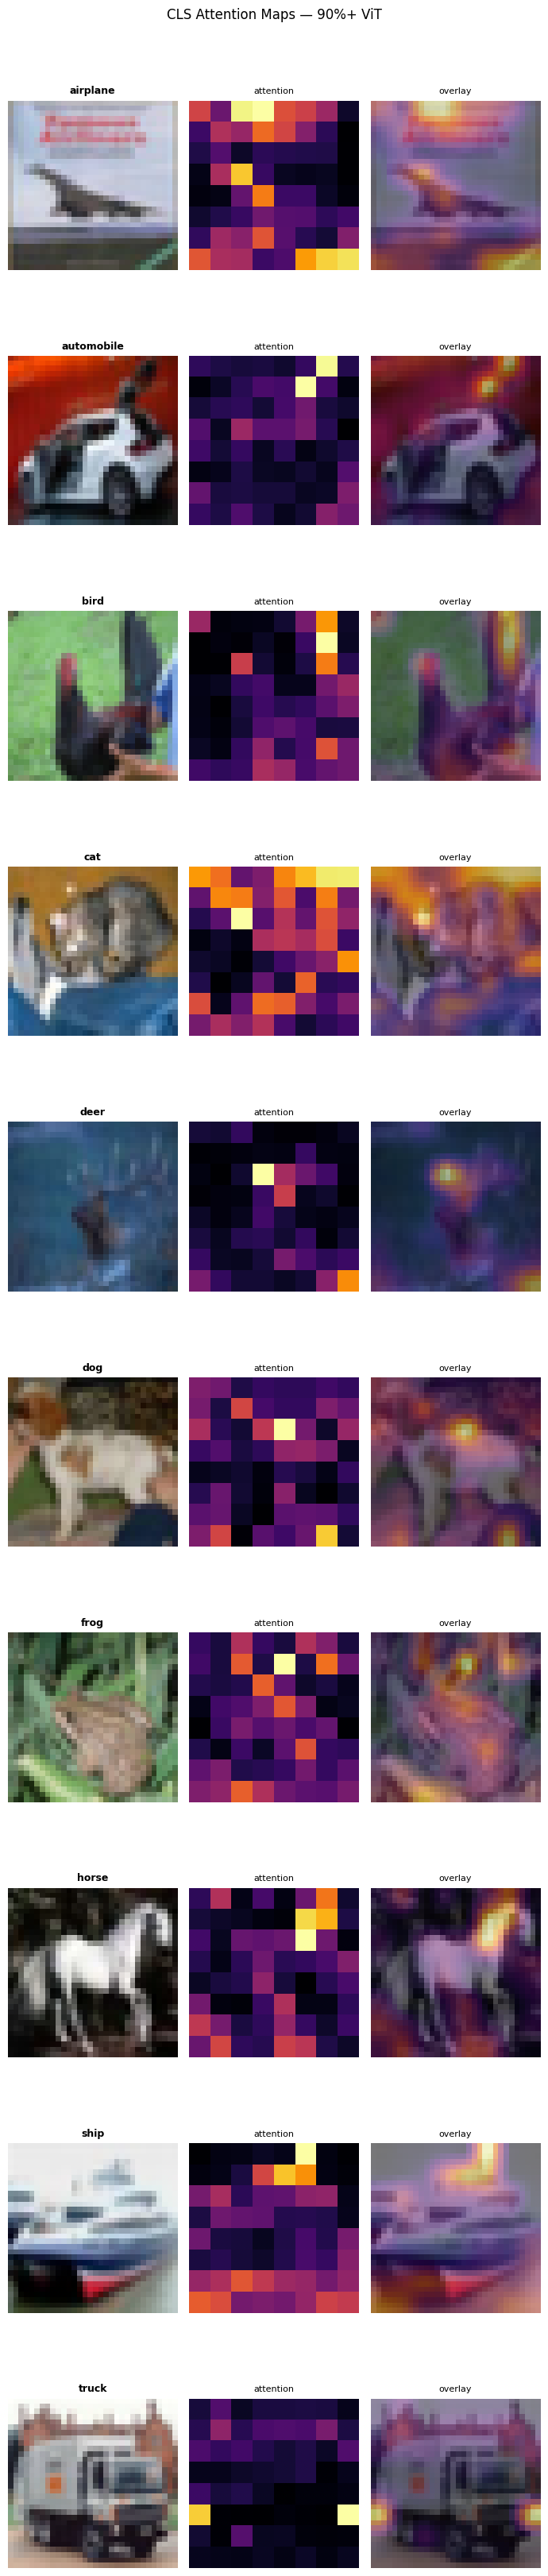

In [23]:

def get_attn_map(model, img_tensor):
    model.eval()
    with torch.no_grad():
        _, all_attns = model(img_tensor.unsqueeze(0).to(DEVICE), output_attentions=True)
    last = all_attns[-1][0]          # (heads, seq, seq)
    cls  = last.mean(0)[0, 1:]       # avg heads → CLS row → patches
    cls  = cls.cpu().numpy()
    G    = int(math.sqrt(len(cls)))
    cls  = cls.reshape(G, G)
    cls  = (cls - cls.min()) / (cls.max() - cls.min() + 1e-8)
    return cls

def unnorm(t):
    m = torch.tensor(CIFAR10_MEAN).view(3,1,1)
    s = torch.tensor(CIFAR10_STD).view(3,1,1)
    return (t.cpu() * s + m).clamp(0,1).permute(1,2,0).numpy()

# Collect one image per class
class_imgs = {}
for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        c = lbl.item()
        if c not in class_imgs:
            class_imgs[c] = img
        if len(class_imgs) == 10:
            break
    if len(class_imgs) == 10:
        break

fig, axes = plt.subplots(10, 3, figsize=(7, 33))
for c in range(10):
    img  = class_imgs[c]
    attn = get_attn_map(model, img)
    orig = unnorm(img)
    attn_up = F.interpolate(
        torch.tensor(attn).unsqueeze(0).unsqueeze(0),
        size=(32,32), mode="bilinear", align_corners=False
    )[0,0].numpy()

    axes[c,0].imshow(orig);        axes[c,0].axis("off")
    axes[c,0].set_title(CLASSES[c], fontsize=9, fontweight="bold")
    axes[c,1].imshow(attn, cmap="inferno"); axes[c,1].axis("off")
    axes[c,1].set_title("attention", fontsize=8)
    axes[c,2].imshow(orig)
    axes[c,2].imshow(attn_up, cmap="inferno", alpha=0.5)
    axes[c,2].axis("off"); axes[c,2].set_title("overlay", fontsize=8)

plt.suptitle("CLS Attention Maps — 90%+ ViT", fontsize=12, y=1.001)
plt.tight_layout()
plt.show()
